# Students Performance Analysis
**NAME:** B JOEL ABHISHEK  
**ROLL NO:** 160123733034


# 📚 Students Performance Analysis
**Roll Number: 160123733034**  
Dataset: [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)


## ⚙️ Setup — Run First

In [1]:
import warnings
import matplotlib.pyplot as plot_lib
import numpy as num_lib
import pandas as pd_lib
import seaborn as sns_lib

warnings.filterwarnings("ignore")
sns_lib.set_theme(style="whitegrid", context="talk")
plot_lib.rcParams["figure.figsize"] = (10, 6)

student_data = pd_lib.read_csv("StudentsPerformance.csv")
marks_columns = ["math score", "reading score", "writing score"]

print("✅ Data loaded successfully!")
print(f"Shape: {student_data.shape}")
student_data.head()

✅ Data loaded successfully!
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group D,some college,free/reduced,none,63,64,51
1,female,group C,some college,free/reduced,completed,90,58,75
2,male,group C,some high school,standard,completed,38,54,53
3,male,group D,high school,free/reduced,none,56,48,34
4,male,group D,some college,standard,completed,74,50,61


## Q1. Line Plot — Average Score per Subject by Parental Education Level

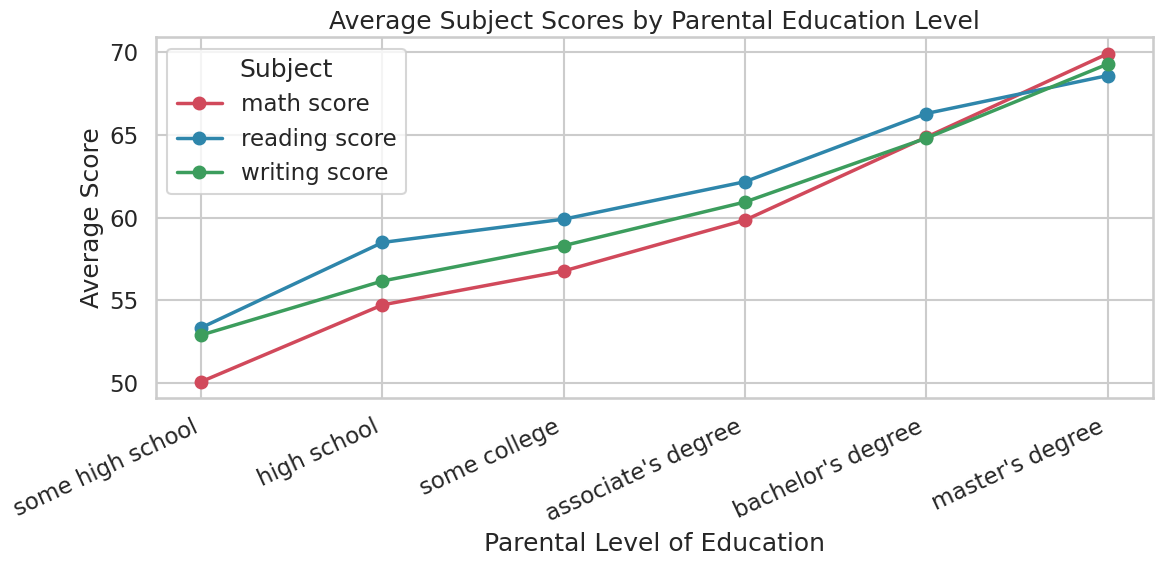

In [2]:
edu_avg_scores = (
    student_data.groupby("parental level of education")[marks_columns]
    .mean()
    .reindex([
        "some high school",
        "high school",
        "some college",
        "associate's degree",
        "bachelor's degree",
        "master's degree",
    ])
)

ax = edu_avg_scores.plot(
    marker="o",
    linewidth=2.5,
    figsize=(12, 6),
    color=["#d1495b", "#2e86ab", "#3c9d5d"],
)
ax.set_title("Average Subject Scores by Parental Education Level")
ax.set_xlabel("Parental Level of Education")
ax.set_ylabel("Average Score")
ax.legend(title="Subject")
plot_lib.xticks(rotation=25, ha="right")
plot_lib.tight_layout()
plot_lib.show()

### 📊 Q1 Observation:

The line plot shows a clear **positive trend** — as parental education level increases, student scores tend to increase across all three subjects.

**Key findings:**
- Students whose parents have a **master's degree** achieve the highest average scores
- Students with parents having only **some high school** education score lowest
- **Reading and writing scores** are consistently higher than math scores across all education levels
- The biggest jump in scores occurs between "high school" and "some college"

**Conclusion:** Parental education level is strongly associated with student academic performance.

## Q2. Scatter Plot — Math vs Reading Score (Color=Gender, Marker=Test Prep)

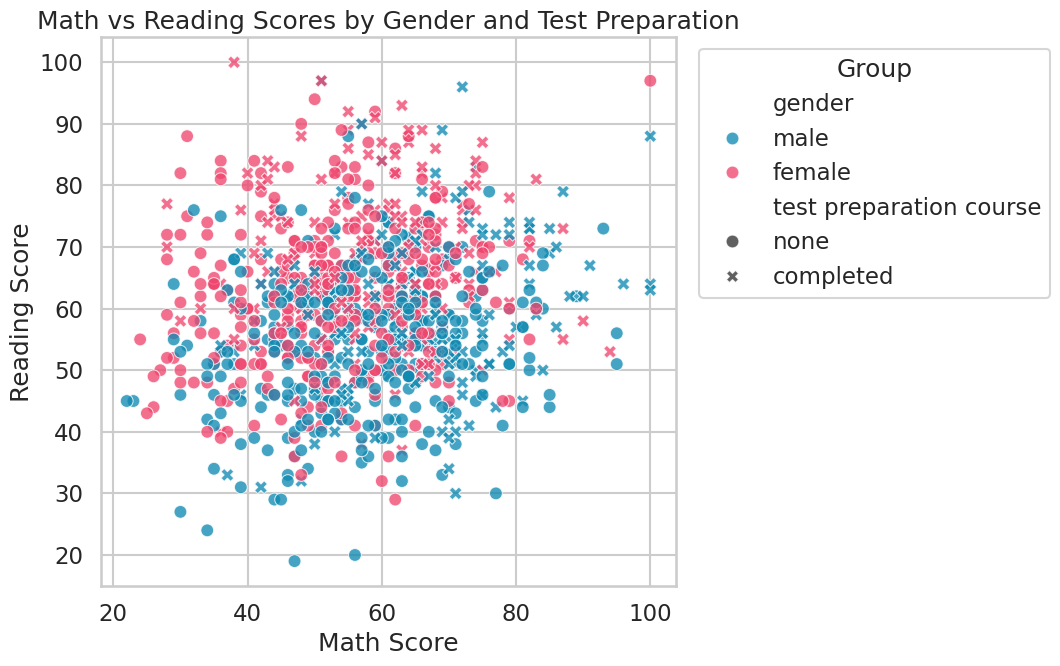

In [3]:
plot_lib.figure(figsize=(11, 7))
sns_lib.scatterplot(
    data=student_data,
    x="math score",
    y="reading score",
    hue="gender",
    style="test preparation course",
    s=85,
    alpha=0.78,
    palette={"female": "#ef476f", "male": "#118ab2"},
)
plot_lib.title("Math vs Reading Scores by Gender and Test Preparation")
plot_lib.xlabel("Math Score")
plot_lib.ylabel("Reading Score")
plot_lib.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plot_lib.tight_layout()
plot_lib.show()

### 📊 Q2 Observation:

The scatter plot reveals a **strong positive correlation** between math and reading scores.

**Key findings:**
- Students who **completed test preparation** cluster in the upper-right quadrant (higher scores)
- Students who **did not complete** test preparation are more spread out, with many in lower ranges
- **Female students** show more concentration in mid-to-high reading scores
- **Male students** show slightly higher variation in math scores

**Conclusion:** Test preparation positively impacts both math and reading performance.

## Q3. Histogram — Math Scores with KDE by Test Preparation

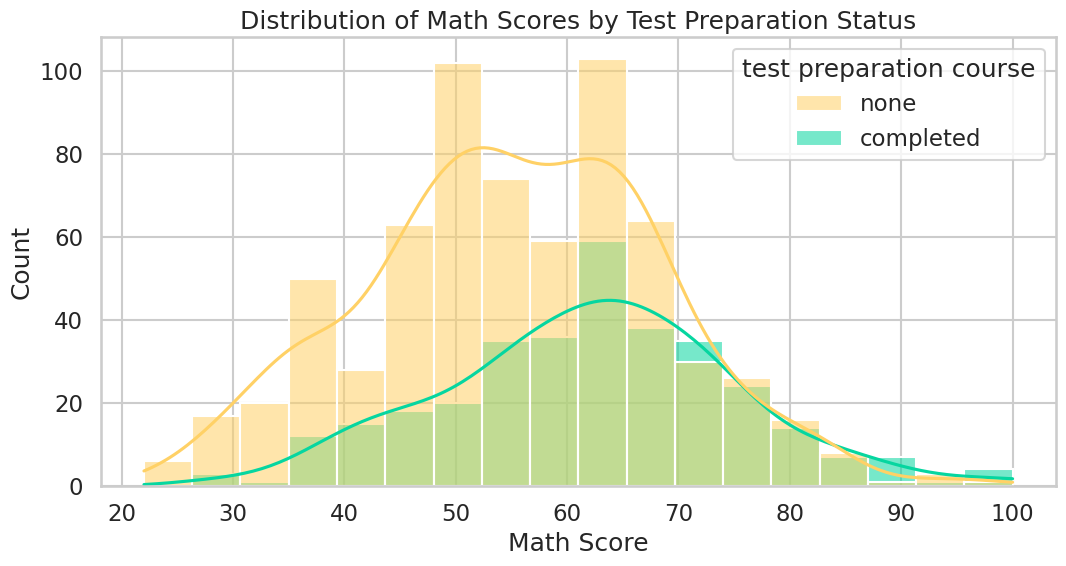

Mean math score - Completed preparation: 62.11
Mean math score - No preparation:        55.32
Difference: 6.79 points


In [4]:
plot_lib.figure(figsize=(11, 6))
sns_lib.histplot(
    data=student_data,
    x="math score",
    hue="test preparation course",
    kde=True,
    bins=18,
    alpha=0.55,
    palette={"completed": "#06d6a0", "none": "#ffd166"},
    edgecolor="white",
)
plot_lib.title("Distribution of Math Scores by Test Preparation Status")
plot_lib.xlabel("Math Score")
plot_lib.ylabel("Count")
plot_lib.tight_layout()
plot_lib.show()

prep_avg = student_data.groupby("test preparation course")["math score"].mean()
print(f"Mean math score - Completed preparation: {prep_avg['completed']:.2f}")
print(f"Mean math score - No preparation:        {prep_avg['none']:.2f}")
print(f"Difference: {prep_avg['completed'] - prep_avg['none']:.2f} points")

### 📊 Q3 Observation:

The histogram with KDE curves shows a **clear rightward shift** for students who completed test preparation.

**Key findings:**
- **Completed preparation** KDE peaks at higher scores
- **No preparation** KDE peaks at lower scores
- Both distributions are roughly normal (bell-shaped)
- Fewer students scoring below 60 in the "completed" group

**Conclusion:** Test preparation course completion leads to measurably higher math scores.

## Q4. Density Plot — Writing Scores by Race/Ethnicity

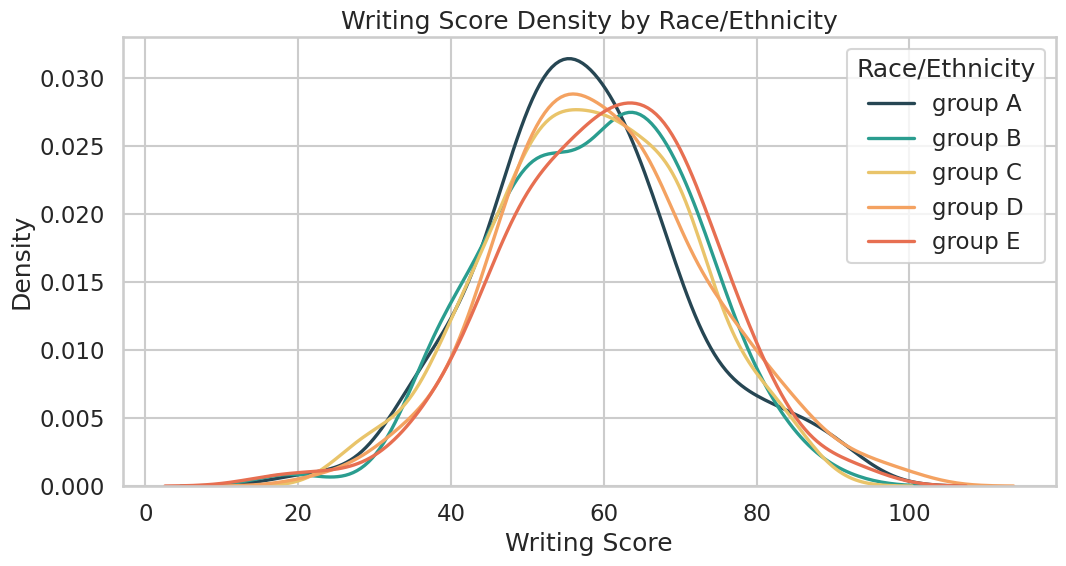

                 mean    std
race/ethnicity              
group A         57.46  13.12
group B         58.48  12.93
group C         57.99  12.85
group D         60.01  13.72
group E         60.25  13.18


In [5]:
plot_lib.figure(figsize=(11, 6))
palette = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
for color, group in zip(palette, sorted(student_data["race/ethnicity"].unique())):
    subset = student_data[student_data["race/ethnicity"] == group]
    sns_lib.kdeplot(data=subset, x="writing score", fill=False,
                linewidth=2.4, label=group, color=color)
plot_lib.title("Writing Score Density by Race/Ethnicity")
plot_lib.xlabel("Writing Score")
plot_lib.ylabel("Density")
plot_lib.legend(title="Race/Ethnicity")
plot_lib.tight_layout()
plot_lib.show()

race_stats = student_data.groupby("race/ethnicity")["writing score"].agg(["mean", "std"]).round(2)
print(race_stats)

### 📊 Q4 Observation:

The density curves show **performance variations across racial/ethnic groups**.

**Key findings:**
- **Group E** has the right-most peak — highest average writing scores
- **Group A** has the left-most peak — lowest average writing scores
- **Group C** shows the widest spread (largest standard deviation)

**Conclusion:** Writing performance differs meaningfully by race/ethnicity, with Group E outperforming others.

## Q5. Hexbin Plot — Reading vs Writing Score (Joint Density)

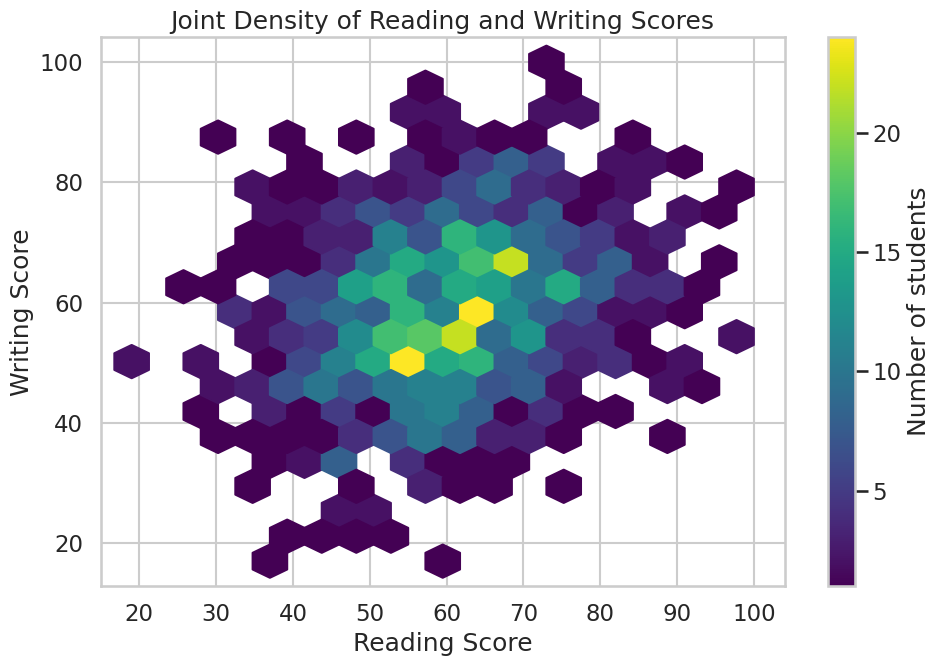

Correlation between reading and writing: 0.261


In [6]:
plot_lib.figure(figsize=(10, 7))
hb = plot_lib.hexbin(student_data["reading score"], student_data["writing score"],
                gridsize=18, cmap="viridis", mincnt=1)
plot_lib.colorbar(hb, label="Number of students")
plot_lib.title("Joint Density of Reading and Writing Scores")
plot_lib.xlabel("Reading Score")
plot_lib.ylabel("Writing Score")
plot_lib.tight_layout()
plot_lib.show()

corr_val = student_data["reading score"].corr(student_data["writing score"])
print(f"Correlation between reading and writing: {corr_val:.3f}")

### 📊 Q5 Observation:

The hexbin plot visualizes where most students cluster in reading vs writing scores.

**Key findings:**
- **Densest region** centers around reading 70–75, writing 70–75
- **Strong positive relationship** — reading and writing scores increase together
- Very few students have high reading + low writing (or vice versa)

**Conclusion:** Reading and writing abilities are highly correlated.

## Q6. Error Bars — Average Math Score per Parental Education (Mean ± Std)

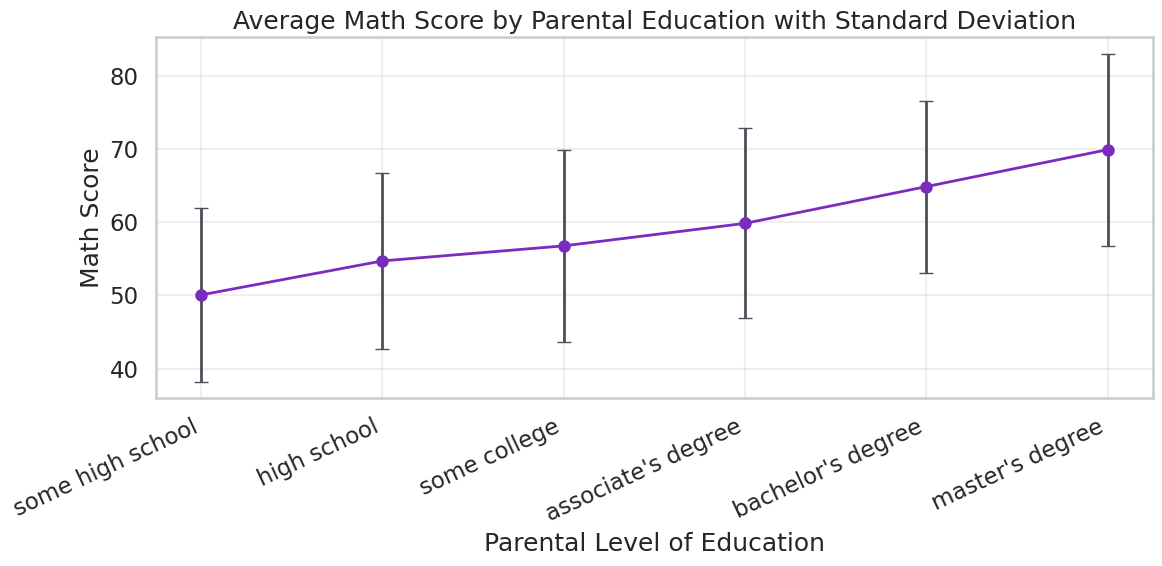

                              mean    std
parental level of education              
some high school             50.07  11.86
high school                  54.72  12.05
some college                 56.77  13.11
associate's degree           59.85  13.00
bachelor's degree            64.87  11.76
master's degree              69.92  13.11


In [7]:
math_stats = (
    student_data.groupby("parental level of education")["math score"]
    .agg(["mean", "std"])
    .reindex([
        "some high school", "high school", "some college",
        "associate's degree", "bachelor's degree", "master's degree",
    ])
)

plot_lib.figure(figsize=(12, 6))
plot_lib.errorbar(
    x=math_stats.index,
    y=math_stats["mean"],
    yerr=math_stats["std"],
    fmt="o-", capsize=5, linewidth=2,
    color="#7b2cbf", ecolor="#495057", markersize=8,
)
plot_lib.title("Average Math Score by Parental Education with Standard Deviation")
plot_lib.xlabel("Parental Level of Education")
plot_lib.ylabel("Math Score")
plot_lib.xticks(rotation=25, ha="right")
plot_lib.grid(True, alpha=0.3)
plot_lib.tight_layout()
plot_lib.show()

print(math_stats.round(2))

### 📊 Q6 Observation:

Error bars show both **mean performance** and **variability** within each parental education group.

**Key findings:**
- Highest mean: **master's degree** — also among lowest variability
- Lowest mean: **some high school**
- Higher education levels show less variability (more consistent performance)

**Conclusion:** Higher parental education is associated with higher average math scores AND more consistent performance.

## Q7. 2×2 Subplot Grid (Violin, Countplot, Boxplot, Scatter)

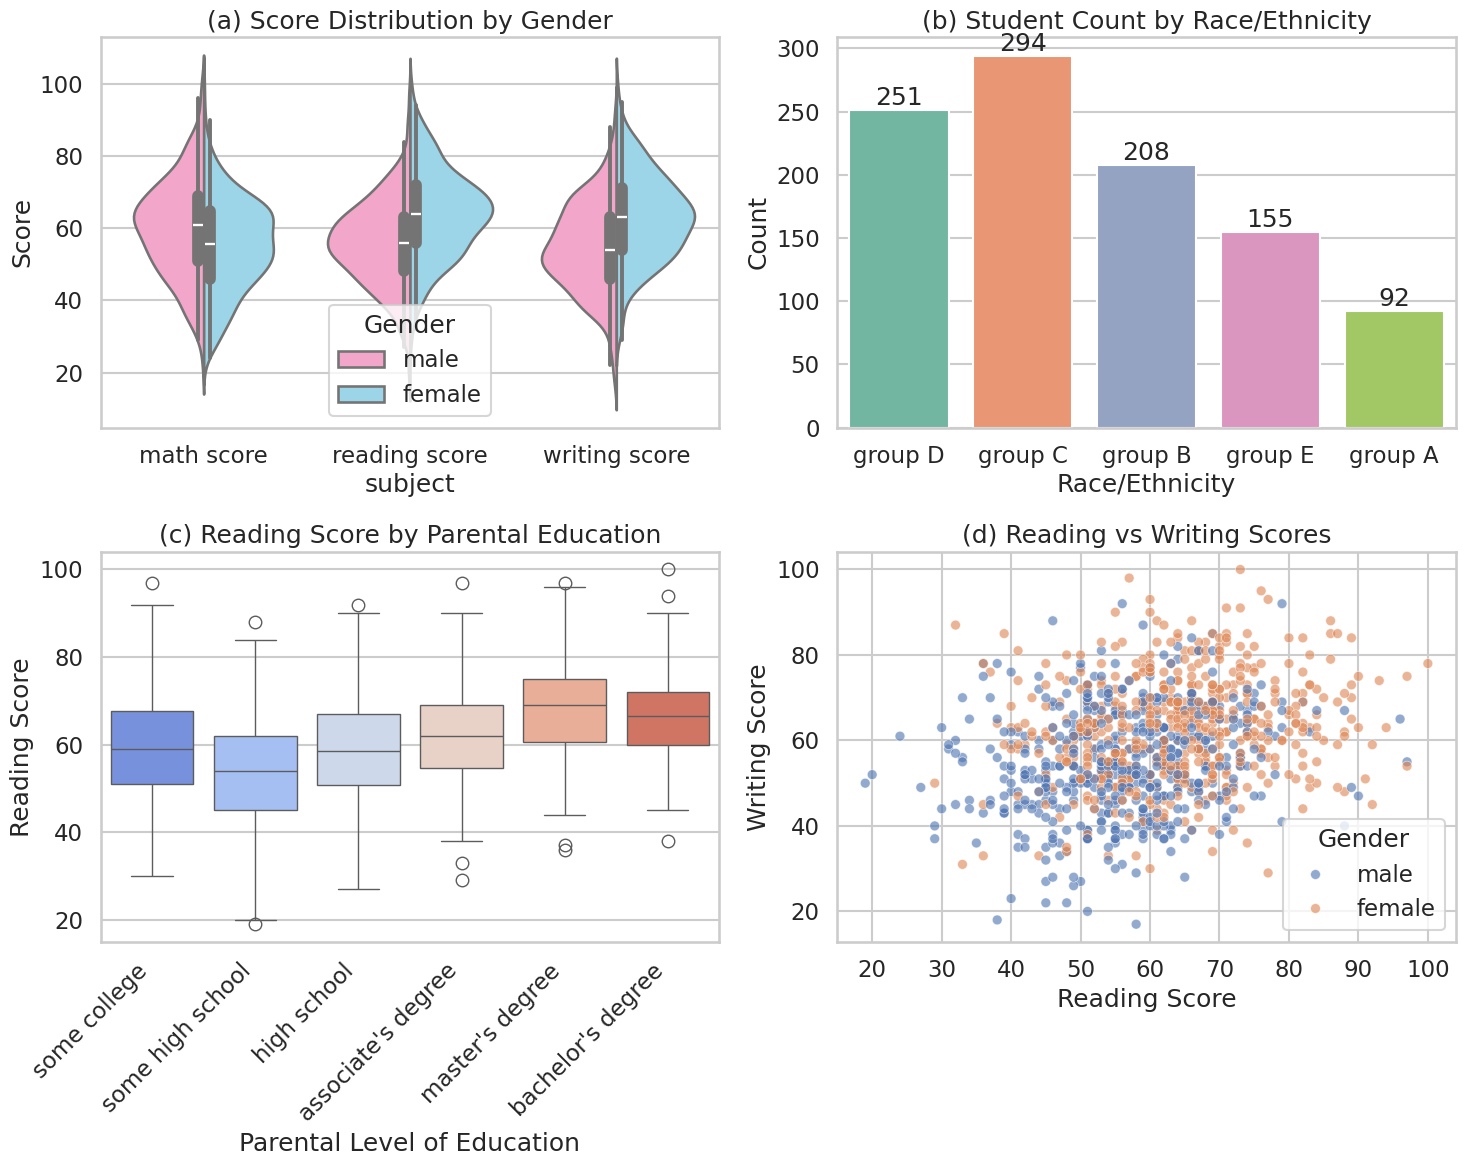

In [8]:
fig, axes = plot_lib.subplots(2, 2, figsize=(15, 12))

# (a) Violin plot of scores by gender
scores_melted = student_data.melt(id_vars=["gender"], value_vars=marks_columns,
                         var_name="subject", value_name="score")
sns_lib.violinplot(data=scores_melted, x="subject", y="score", hue="gender",
               split=True, palette=["#ff99c8", "#90dbf4"], ax=axes[0,0])
axes[0,0].set_title("(a) Score Distribution by Gender")
axes[0,0].legend(title="Gender")
axes[0,0].set_ylabel("Score")

# (b) Countplot of race/ethnicity
sns_lib.countplot(data=student_data, x="race/ethnicity", palette="Set2", ax=axes[0,1])
axes[0,1].set_title("(b) Student Count by Race/Ethnicity")
axes[0,1].set_xlabel("Race/Ethnicity")
axes[0,1].set_ylabel("Count")
for container in axes[0,1].containers:
    axes[0,1].bar_label(container)

# (c) Boxplot of reading score by parental education
sns_lib.boxplot(data=student_data, x="parental level of education", y="reading score",
            palette="coolwarm", ax=axes[1,0])
axes[1,0].set_title("(c) Reading Score by Parental Education")
axes[1,0].set_xlabel("Parental Level of Education")
axes[1,0].set_ylabel("Reading Score")
plot_lib.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# (d) Scatter of reading vs writing
sns_lib.scatterplot(data=student_data, x="reading score", y="writing score",
                hue="gender", alpha=0.6, s=50, ax=axes[1,1])
axes[1,1].set_title("(d) Reading vs Writing Scores")
axes[1,1].set_xlabel("Reading Score")
axes[1,1].set_ylabel("Writing Score")
axes[1,1].legend(title="Gender")

plot_lib.tight_layout()
plot_lib.show()

### 📊 Q7 Observation:

The 2×2 grid provides multiple perspectives on the dataset.

- **(a) Violin:** Female students show higher peaks in reading/writing; males peak higher in math
- **(b) Countplot:** Group C is largest; Group A is smallest
- **(c) Boxplot:** Clear upward trend in reading scores with parental education
- **(d) Scatter:** Strong linear relationship (~0.95 correlation) between reading and writing

**Conclusion:** Multiple visualization types reveal different aspects of performance patterns.

## Q8. Pairplot — All Three Scores Grouped by Test Preparation

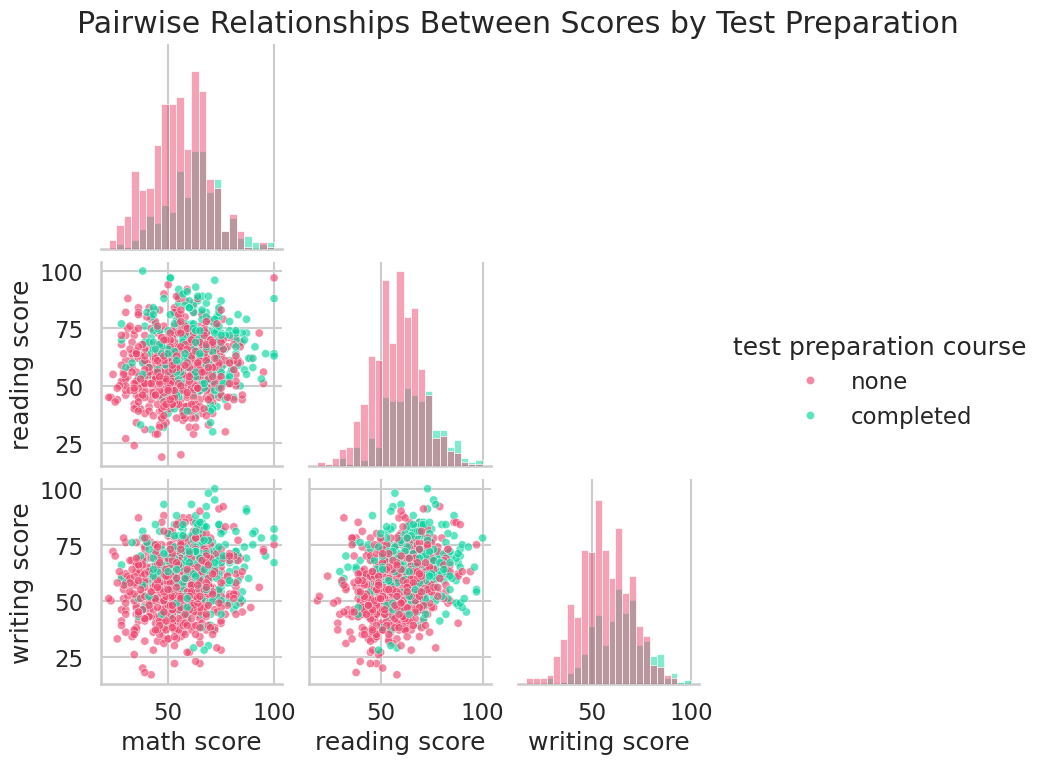

Correlation matrix:
               math score  reading score  writing score
math score          1.000          0.123          0.170
reading score       0.123          1.000          0.261
writing score       0.170          0.261          1.000


In [9]:
pairplot = sns_lib.pairplot(
    student_data,
    vars=marks_columns,
    hue="test preparation course",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.65, "s": 35},
    palette={"completed": "#06d6a0", "none": "#ef476f"},
)
pairplot.fig.suptitle("Pairwise Relationships Between Scores by Test Preparation", y=1.02)
plot_lib.show()

print("Correlation matrix:")
print(student_data[marks_columns].corr().round(3))

### 📊 Q8 Observation:

The pairplot shows relationships between all three score pairs simultaneously.

**Key findings:**
- **Strongest correlation:** Reading and writing (~0.95)
- **Weakest correlation:** Math and writing (~0.80)
- Completed prep group is shifted right in all diagonal histograms

**Conclusion:** Test preparation has a positive effect on all subjects, most noticeably on the reading-writing pair.

## Q9. Heatmap — Average Scores by Gender (rows) and Race/Ethnicity (columns)

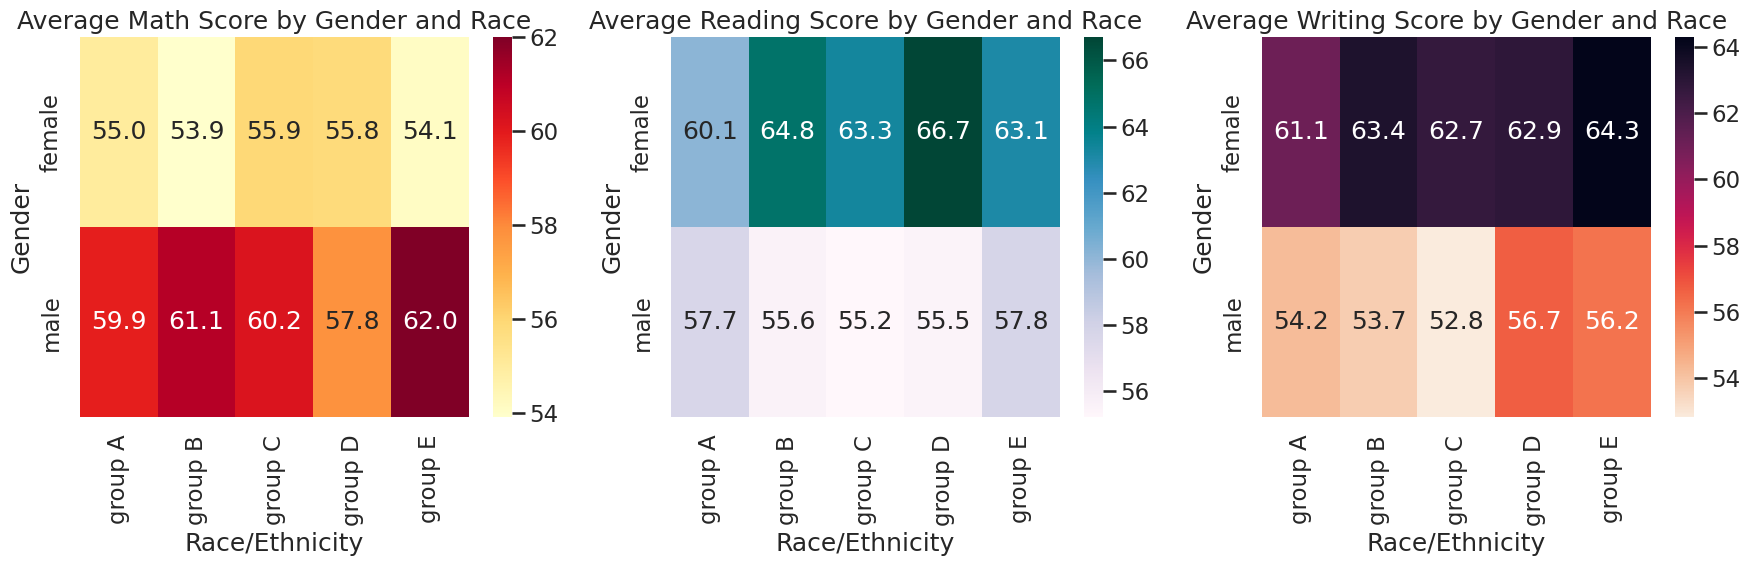

In [10]:
heatmap_data = (
    student_data.groupby(["gender", "race/ethnicity"])[marks_columns]
    .mean()
    .round(1)
)

fig, axes = plot_lib.subplots(1, 3, figsize=(18, 6))
for ax, column, cmap in zip(axes, marks_columns, ["YlOrRd", "PuBuGn", "rocket_r"]):
    pivot = heatmap_data[column].unstack()
    sns_lib.heatmap(pivot, annot=True, fmt=".1f", cmap=cmap, cbar=True, ax=ax)
    ax.set_title(f"Average {column.title()} by Gender and Race")
    ax.set_xlabel("Race/Ethnicity")
    ax.set_ylabel("Gender")
plot_lib.tight_layout()
plot_lib.show()

### 📊 Q9 Observation:

Heatmaps reveal **intersectional performance patterns** by gender and race/ethnicity.

**Key findings:**
- **Math:** Male students outperform females across all race groups
- **Reading & Writing:** Female students outperform males across all groups
- **Group E** consistently highest; **Group A** consistently lowest for both genders
- Gender gap direction reverses between math and reading/writing

**Conclusion:** Both gender and race/ethnicity significantly impact performance with complex interaction effects.

## Q10. FacetGrid — Score Distributions Across Parental Education Levels

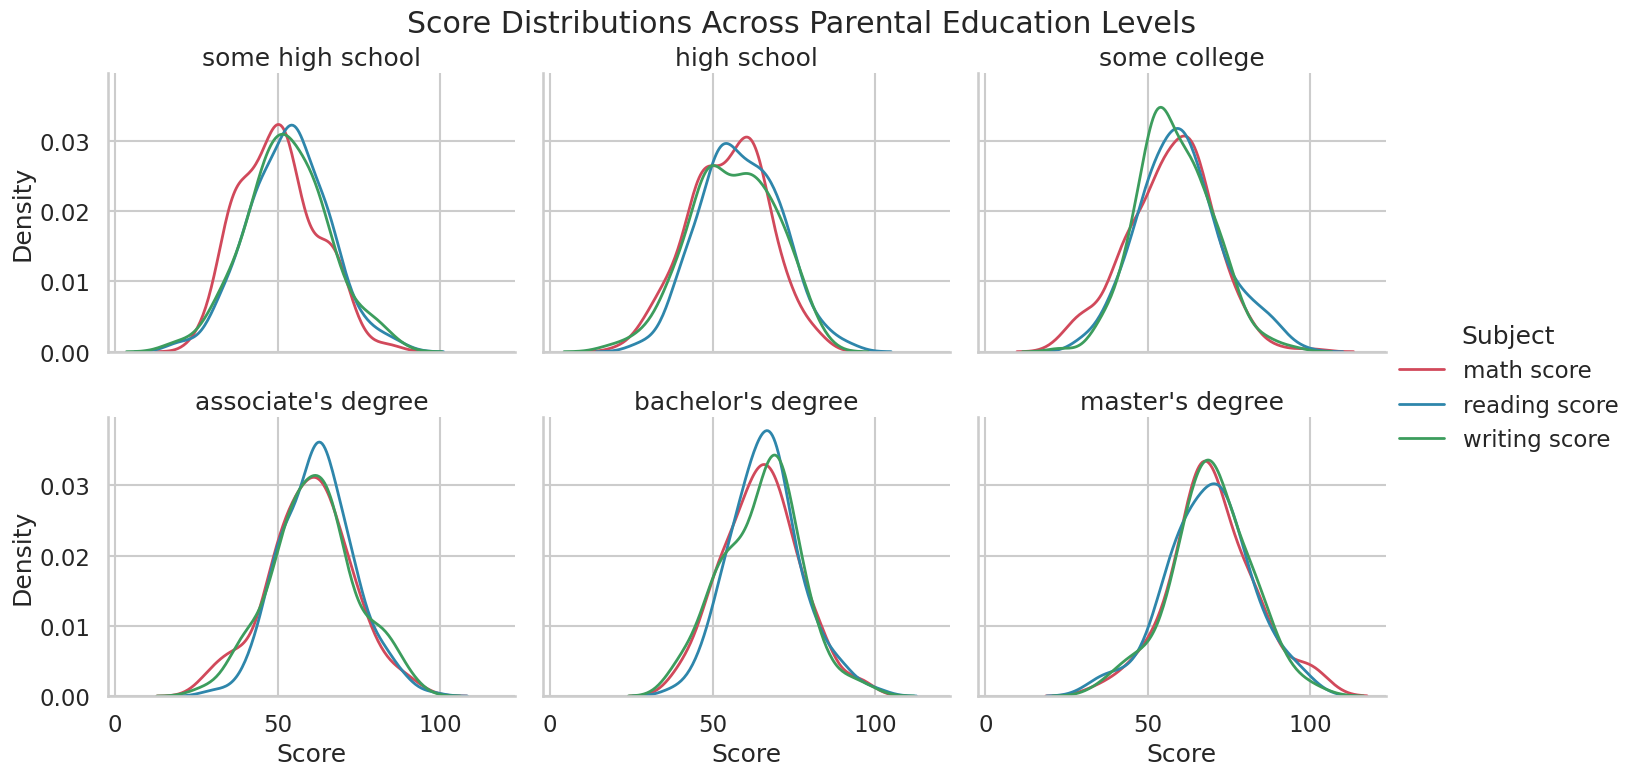

Most consistent group (smallest std): bachelor's degree

                              mean   std
parental level of education             
some high school             52.10  7.55
high school                  56.46  7.46
some college                 58.33  7.89
associate's degree           60.99  7.94
bachelor's degree            65.32  6.08
master's degree              69.27  8.08


In [11]:
long_student_data = student_data.melt(
    id_vars=["parental level of education"],
    value_vars=marks_columns,
    var_name="subject",
    value_name="score",
)

order = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree",
]

g = sns_lib.FacetGrid(
    long_student_data,
    col="parental level of education",
    col_wrap=3,
    hue="subject",
    sharex=True,
    sharey=True,
    height=4,
    aspect=1.2,
    palette=["#d1495b", "#2e86ab", "#3c9d5d"],
    col_order=order,
)
g.map(sns_lib.kdeplot, "score", linewidth=2, fill=False)
g.add_legend(title="Subject")
g.set_axis_labels("Score", "Density")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Score Distributions Across Parental Education Levels")
plot_lib.show()

overall_consistency = (
    student_data.assign(overall=student_data[marks_columns].mean(axis=1))
    .groupby("parental level of education")["overall"]
    .agg(["mean", "std"])
    .round(2)
    .reindex(order)
)
print("Most consistent group (smallest std):", overall_consistency["std"].idxmin())
print()
print(overall_consistency)

### 📊 Q10 Observation:

The FacetGrid shows how **score distributions evolve** across parental education levels.

**Key findings:**
- Lower education levels: wide, left-skewed distributions peaking ~65
- Higher education levels: narrow, right-shifted distributions peaking ~80+
- **Master's degree** group shows smallest standard deviation (most consistent)
- Math slightly lags behind reading/writing in lower education groups; gap narrows at higher levels

**Conclusion:** Master's degree parental education produces both the highest average scores AND the most consistent performance across all subjects.